In [1]:
from itertools import product

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

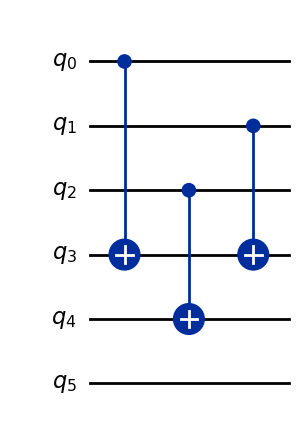

In [2]:
def create_simon_oracle():
    """
    Oráculo de Simon para o segredo s = 110.

    Ordem lógica:
        entrada = (x0, x1, x2)

    Função:
        f(x0, x1, x2) = (x0 XOR x1, x2, 0)
    """

    oracle = QuantumCircuit(6, name="U_f")

    # Primeiro bit da saída: y0 = x0 XOR x1
    oracle.cx(0, 3)
    oracle.cx(1, 3)

    # Segundo bit da saída: y1 = x2
    oracle.cx(2, 4)

    # O terceiro bit da saída permanece em 0

    return oracle


oracle = create_simon_oracle()

display(oracle.draw("mpl"))
plt.show()

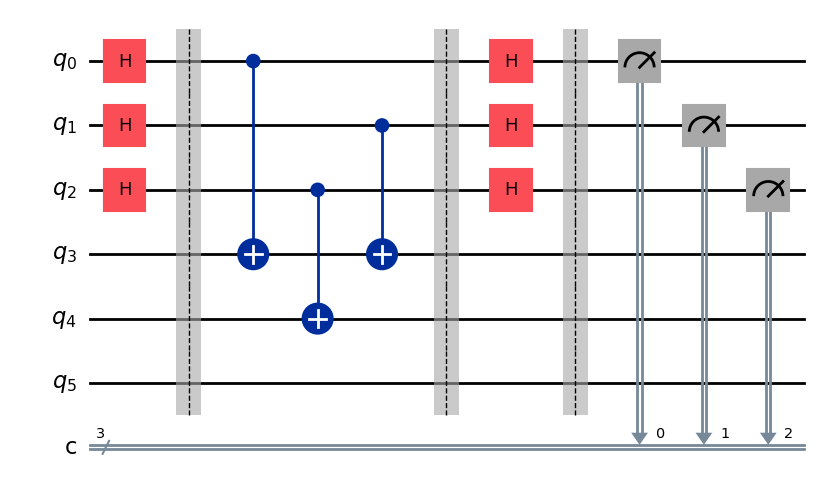

In [3]:
def create_simon_circuit():
    n = 3

    # 3 qubits de entrada + 3 qubits de saída
    # 3 bits clássicos para medir o primeiro registrador
    circuit = QuantumCircuit(2 * n, n)

    # Coloca todas as entradas em superposição
    circuit.h([0, 1, 2])

    circuit.barrier()

    # Aplica o oráculo
    circuit.compose(
        create_simon_oracle(),
        qubits=range(6),
        inplace=True
    )

    circuit.barrier()

    # Segunda camada de Hadamard
    circuit.h([0, 1, 2])

    circuit.barrier()

    # Mede apenas os qubits de entrada
    circuit.measure([0, 1, 2], [0, 1, 2])

    return circuit


simon_circuit = create_simon_circuit()

display(simon_circuit.draw("mpl"))
plt.show()

In [4]:
simulator = AerSimulator()
shots = 1024

compiled_circuit = transpile(
    simon_circuit,
    simulator,
    optimization_level=1
)

job = simulator.run(
    compiled_circuit,
    shots=shots
)

result = job.result()
counts = result.get_counts()

print("Resultados obtidos:")
print(counts)

plot_histogram(
    counts,
    title="Algoritmo de Simon — segredo s = 110"
)

plt.show()

Resultados obtidos:
{'100': 265, '111': 282, '011': 245, '000': 232}


In [5]:
def qiskit_to_logical_order(bitstring):
    """
    Qiskit mostra c2 c1 c0.
    Esta função converte para y0 y1 y2.
    """

    bitstring = bitstring.replace(" ", "")
    return tuple(int(bit) for bit in bitstring[::-1])


def dot_product_mod2(vector_a, vector_b):
    """
    Produto interno módulo 2.
    """

    return sum(
        a * b
        for a, b in zip(vector_a, vector_b)
    ) % 2


# Resultados diferentes observados
measured_vectors = [
    qiskit_to_logical_order(bitstring)
    for bitstring in counts.keys()
]

print("Vetores medidos na ordem lógica y0, y1, y2:")

for vector in measured_vectors:
    print(vector)

Vetores medidos na ordem lógica y0, y1, y2:
(0, 0, 1)
(1, 1, 1)
(1, 1, 0)
(0, 0, 0)


In [6]:
possible_secrets = []

for candidate in product([0, 1], repeat=3):

    # Simon procura um segredo não nulo
    if candidate == (0, 0, 0):
        continue

    valid_candidate = all(
        dot_product_mod2(measured, candidate) == 0
        for measured in measured_vectors
    )

    if valid_candidate:
        possible_secrets.append(candidate)


print("\nSoluções plausíveis:")

for candidate in possible_secrets:
    print(candidate)


Soluções plausíveis:
(1, 1, 0)
